## Excitation energy $^{16}\text{O}$ other decay channels

In [1]:
from spyral.core.constants import AMU_2_MEV, QBRHO_2_P

from spyral_utils.nuclear import NuclearDataMap
from spyral_utils.nuclear.target import GasTarget, load_target, SolidTarget
from spyral_utils.plot import Histogrammer

import polars as pl
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import vector
import lmfit
from itertools import combinations
import json
%matplotlib widget
plt.close()

nuclear_map = NuclearDataMap()
# Ion Chamber entrance and exit window, thickness in ug/cm^2
ic_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# AT-TPC entrance window, thickness in ug/cm^2
attpc_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# Ion Chamber gas material, pressure in Torr
ic_gas_material = GasTarget(compound=[(6,12,1),(9,18,4)], pressure=200.0, nuclear_data=nuclear_map)
ic_gas_thickness = 0.035 #m


In [2]:
nuclear_map = NuclearDataMap()

# Set some parameters
# workspace_path_target = Path("/Volumes/research_EXT_2/spyral_target_alpha_width3")
# workspace_path_decay = Path("/Volumes/research_EXT_2/spyral_decay_alpha_width3")

# solver_result_path_target = workspace_path_target / "InterpSolver"
# solver_result_path_decay = workspace_path_decay / "InterpSolver"
solver_result_path = Path("/Volumes/researchEXT/O16/all_analysis_spyralv1.0/all_five_tracks_analysis/14082026_all_5tracks") / "InterpSolver"
# Your AT-TPC target gas material
target_material_path = Path("/Users/pranjalsingh/Desktop/research_space_spyral/e20020_analysis/solver_gas_16O.json")

# Run number range (inclusive)
run_min = 54
run_max = 170
# Specify your nuclei

# The nucleus we observe (the one we fitted)
ejectile_z = 2
ejectile_a = 4

# The incoming nucleus (the beam)
projectile_z = 8
projectile_a = 16


channel_z = 6
channel_a = 12 

channel2_z = 4
channel2_a = 8

fusion_z = 10
fusion_a = 20

# The target nucleus
target_z = 2
target_a = 4

# We calculate the residual for you
residual_z = target_z + projectile_z - ejectile_z
residual_a = target_a + projectile_a - ejectile_a


if residual_z < 0:
    raise Exception(f"Illegal nuclei! Residual Z: {residual_z}")  # noqa: TRY002
if residual_a < 1:
    raise Exception(f"Illegal nuclei! Residual A: {residual_a}")  # noqa: TRY002


In [3]:
target_material = load_target(target_material_path, nuclear_map)
if not isinstance(target_material, GasTarget):
    print('Target error!')

ejectile = nuclear_map.get_data(ejectile_z, ejectile_a)
projectile = nuclear_map.get_data(projectile_z, projectile_a)
channel = nuclear_map.get_data(channel_z, channel_a)
channel_8be = nuclear_map.get_data(channel2_z, channel2_a)
fusion = nuclear_map.get_data(fusion_z, fusion_a)
target = nuclear_map.get_data(target_z, target_a)
residual = nuclear_map.get_data(residual_z, residual_a)
print(f"Reaction: {target}({projectile}, {ejectile}){residual}")
print(f"Target material: {target_material.ugly_string}")

# Initial beam energy
mass_amu = projectile.mass / AMU_2_MEV # If needed, to convert beam energy in MeV/u -> MeV
proj_energy_accel = 161.0 # MeV, the beam energy from the accelerator

# The beam energy after the ic entrance window
proj_energy_ic = proj_energy_accel #- ic_window_material.get_energy_loss(projectile, proj_energy_accel, np.array([0.0]))[0]
# The beam energy after the ic gas
proj_energy_ic_exit = proj_energy_ic #- ic_gas_material.get_energy_loss(projectile, proj_energy_ic, np.array([ic_gas_thickness]))[0]
# The beam energy after the ic exit window
proj_energy_post_ic = proj_energy_ic_exit #- ic_window_material.get_energy_loss(projectile, proj_energy_ic_exit, np.array([0.0]))[0]
# The beam energy after the AT-TPC entrace window
proj_energy_start = proj_energy_post_ic #- attpc_window_material.get_energy_loss(projectile, proj_energy_post_ic, np.array([0.0]))[0]
# The beam energy at the downstream end of the AT-TPC
proj_energy_stop = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, np.array([1.0]))[0] # Energy at far end of detector
print(f"Accelerator Beam energy: {proj_energy_accel} MeV")
print(f"Beam energy after IC (2 windows + gas): {proj_energy_post_ic} MeV")
print(f"Beam energy range in AT-TPC: {proj_energy_start}-{proj_energy_stop} MeV")


Reaction: 4He(16O, 4He)16O
Target material: (Gas)4He1
Accelerator Beam energy: 161.0 MeV
Beam energy after IC (2 windows + gas): 161.0 MeV
Beam energy range in AT-TPC: 161.0-110.84634259864373 MeV


In [4]:
grammer = Histogrammer()
grammer.add_hist1d('inv_12c', 100, (0, 40.0))
grammer.add_hist1d('inv_8be', 25, (-0.1, 0.4))

In [5]:
def inv_mass_12c(decay_alphas):
    """This fucntion calcualtes the invariant mass energy 

    Args:
        decay_alphas (list): list of dicts of decay alphas 

    Returns:
        float: invariant mass energy
    """
    total_E, px_tot, py_tot, pz_tot = 0,0,0,0
    
    for row in decay_alphas:
        brho = row["brho"]
        momentum = brho * float(ejectile.Z) * QBRHO_2_P
        
        polar = row["polar"]
        az = row["azimuthal"]
        
        energy = np.sqrt(momentum**2.0 + ejectile.mass**2.0)
        
        total_E += energy
        px_tot += momentum * np.sin(polar) * np.cos(az)
        py_tot += momentum * np.sin(polar) * np.sin(az)
        pz_tot += momentum * np.cos(polar)
        
    p_tot = np.sqrt(px_tot**2 + py_tot**2 + pz_tot**2)
        
    inv_mass = np.sqrt(total_E**2 - p_tot**2)
    inv_energy = inv_mass - channel.mass
    
    return inv_energy

## $^{12}\text{C}$ + $2\alpha$

In [ ]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

counter_inv = 0
inv_energy_arr = []

counter = 0

for run in range(run_min, run_max + 1):
    path = solver_result_path / f"run_{run:04d}_4He.parquet"
    
    if not path.exists():
        continue

    df = pl.scan_parquet(path).collect()
    df = df.with_row_index("row_id")
    counts = (
            df
            .group_by("event")
            .len()
        )

    valid_events = (
        counts
        .filter(pl.col("len") == 5)
        .select("event")
    )

    df = df.join(
        valid_events,
        on="event",
        how="inner"
    )
    
    
    # print(df)
    counter += len(np.unique(df["event"])) #total number of 5 tracks 
    
    for event in np.unique(df["event"]):
        # if event != 195241:
        #     continue
        event_df = df.filter(pl.col("event") == event)
        counter_inv +=1
        alphas = list(event_df.iter_rows(named=True))
        assert len(alphas) == 5
        # print(alphas)
        for selected_alphas in combinations(alphas, 3):
            # print([alpha["cluster_index"] +1 for alpha in selected_alphas])
            invariant_energy = inv_mass_12c(selected_alphas)
            if invariant_energy > 8:
                continue
            else:
                inv_energy_arr.append(invariant_energy)
            # print(f"Combination: {[alpha["cluster_index"] +1 for alpha in selected_alphas]} | Invariant Energy: {invariant_energy:.2f} MeV")

print(counter_inv)      
print(len(inv_energy_arr))            
grammer.fill_hist1d("inv_12c",inv_energy_arr)


307
18


True

In [7]:
def double_gaussian(x, a1, mu1, sig1, a2, mu2, sig2):
    g1 = a1 * np.exp(-((x - mu1) ** 2) / (2 * sig1 ** 2))
    g2 = a2 * np.exp(-((x - mu2) ** 2) / (2 * sig2 ** 2))
    return g1 + g2

initial_guess = [0.3, 14.0, 5, 0.4, 12, 1.0]
# initial_guess = [1,1,1,1,1,1]

18


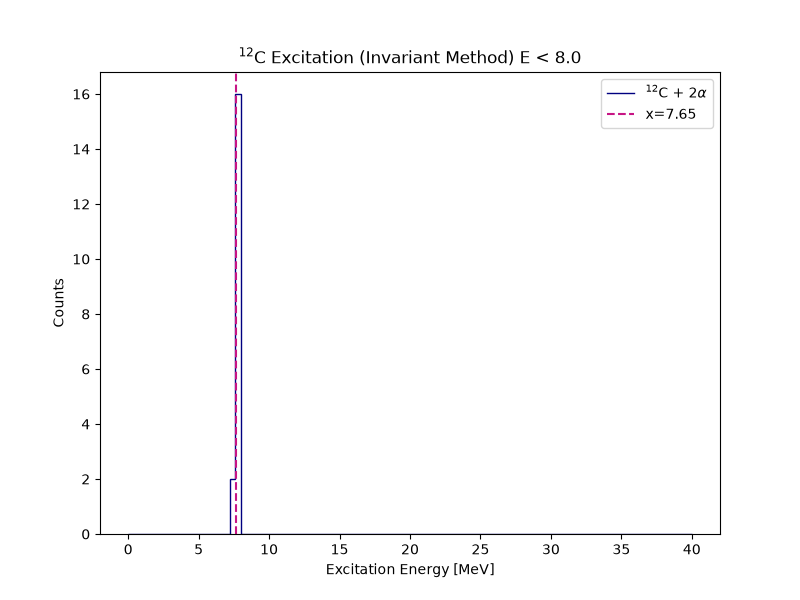

In [17]:
from scipy.optimize import curve_fit

fig, ax = plt.subplots(1,1)
hist = grammer.get_hist1d("inv_12c")
print(np.sum(hist.counts))
# print(hist.bins)
bin_centers = (hist.bins[:-1] + hist.bins[1:])/2

# popt, pcov = curve_fit(double_gaussian, bin_centers, hist.counts, p0=initial_guess)
# x_smooth = np.linspace(hist.bins[0], hist.bins[-1], 200)
# y_fit = double_gaussian(x_smooth, *popt)
# y_gauss1 = popt[0] * np.exp(-((x_smooth - popt[1]) ** 2) / (2 * popt[2] ** 2))
# y_gauss2 = popt[3] * np.exp(-((x_smooth - popt[4]) ** 2) / (2 * popt[5] ** 2))

ax.stairs(hist.counts, edges=hist.bins, color="navy", label=r"$^{12}$C + $2\alpha$")
ax.axvline(x=7.65, linestyle="--", color="mediumvioletred", label="x=7.65")
# plt.plot(x_smooth, y_fit, 'r-', label='Combined Fit', linewidth=2)
# plt.plot(x_smooth, y_gauss1, 'g--', label=rf'Gaussian 1 ($\mu$ = {popt[1]:.2f} | $\sigma$ = {popt[2]:.2f})')
# plt.plot(x_smooth, y_gauss2, 'b--', label=rf'Gaussian 2 ($\mu$ = {popt[4]:.2f} | $\sigma$ = {popt[5]:.2f})')
ax.set_xlabel("Excitation Energy [MeV]")
ax.set_ylabel("Counts")
plt.legend()
plt.title(r"$^{12}$C Excitation (Invariant Method) E < 8.0")
fig.set_figwidth(8.0)
fig.set_figheight(6.0)
plt.show()

In [9]:
def inv_mass_8be(decay_alphas):
    """This fucntion calcualtes the invariant mass energy 

    Args:
        decay_alphas (list): list of dicts of decay alphas 

    Returns:
        float: invariant mass energy
    """
    total_E, px_tot, py_tot, pz_tot = 0,0,0,0
    
    for row in decay_alphas:
        brho = row["brho"]
        momentum = brho * float(ejectile.Z) * QBRHO_2_P
        
        polar = row["polar"]
        az = row["azimuthal"]
        
        energy = np.sqrt(momentum**2.0 + ejectile.mass**2.0)
        
        total_E += energy
        px_tot += momentum * np.sin(polar) * np.cos(az)
        py_tot += momentum * np.sin(polar) * np.sin(az)
        pz_tot += momentum * np.cos(polar)
        
    p_tot = np.sqrt(px_tot**2 + py_tot**2 + pz_tot**2)
        
    inv_mass = np.sqrt(total_E**2 - p_tot**2)
    inv_energy = inv_mass - channel_8be.mass
    
    return inv_energy

In [10]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

counter_inv = 0
inv_energy_arr = []

counter = 0
be8_peakgs = []

for run in range(run_min, run_max + 1):
    path = solver_result_path / f"run_{run:04d}_4He.parquet"
    
    if not path.exists():
        continue

    df = pl.scan_parquet(path).collect()
    df = df.with_row_index("row_id")
    counts = (
            df
            .group_by("event")
            .len()
        )

    valid_events = (
        counts
        .filter(pl.col("len") == 5)
        .select("event")
    )

    df = df.join(
        valid_events,
        on="event",
        how="inner"
    )
    
    # print(df)
    counter += len(np.unique(df["event"])) #total number of 5 tracks 
    
    
    for event in np.unique(df["event"]):
        event_df = df.filter(pl.col("event") == event)
        counter_inv +=1
        alphas = list(event_df.iter_rows(named=True))
        assert len(alphas) == 5
        
        gs_bool = False
        ex_bool = False
        
        inv_arr_evnt_gs = []
        inv_arr_evnt_ex = []
        # print(alphas)
        for selected_alphas in combinations(alphas, 2):
            # print([alpha["cluster_index"] +1 for alpha in selected_alphas])
            cluster_index = [alpha["cluster_index"] for alpha in selected_alphas]
            invariant_energy = inv_mass_8be(selected_alphas)
            
            # if invariant_energy < 0.3:
            #     if not ex_bool:
            #         inv_arr_evnt_gs.append({"run":run,"event":int(event),"cluster_idx":cluster_index})
            #         gs_bool = True
            #     if ex_bool:
            #         be8_peakgs.append({"run":run,"event":int(event),"cluster_idx":cluster_index})
            #         be8_peakgs +=inv_arr_evnt_ex
            #         ex_bool = False
                
            # if invariant_energy > 2.3 and invariant_energy <= 3.2:
            #     if gs_bool:
            #         be8_peakgs.append({"run":run,"event":int(event),"cluster_idx":cluster_index})
            #         be8_peakgs +=inv_arr_evnt_gs
            #         gs_bool = False
            #     if not gs_bool:
            #         inv_arr_evnt_ex.append({"run":run,"event":int(event),"cluster_idx":cluster_index})
            #         ex_bool = True
                    
            inv_energy_arr.append(invariant_energy)

print(counter_inv)      
print(len(inv_energy_arr))            
grammer.fill_hist1d("inv_8be",inv_energy_arr)


307
3070


True

In [11]:
# print(be8_peakgs)
# with open("be8_peak_combined_run_event.json", "w", encoding="utf-8") as file:
#     json.dump(be8_peakgs, file, indent=4)

In [12]:
def single_gaussian(x, a1, mu1, sig1):
    return  a1 * np.exp(-((x - mu1) ** 2) / (2 * sig1 ** 2))


initial_guess = [3, 0, 0.1]

In [13]:
def breit_wigner(x, amplitude, x0, gamma):
  return  amplitude * (gamma / 2.5) / (
      np.pi * ((x - x0) ** 2 + (gamma / 2) ** 2)
)

p0 = [10.0, 0, 0.1]

273


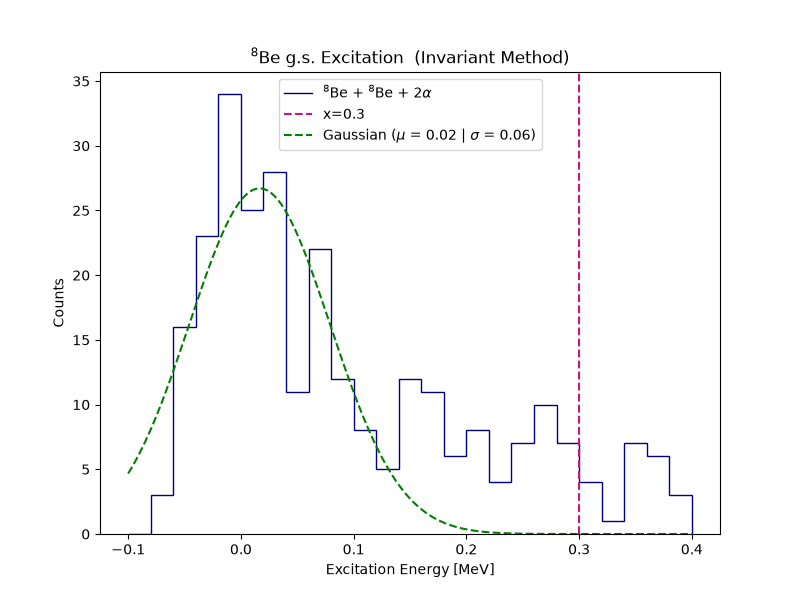

In [14]:
fig, ax = plt.subplots(1,1)
hist = grammer.get_hist1d("inv_8be")
print(np.sum(hist.counts))

bin_centers = (hist.bins[:-1] + hist.bins[1:])/2
popt, pcov = curve_fit(single_gaussian, bin_centers, hist.counts, p0=initial_guess)
x_smooth = np.linspace(hist.bins[0], hist.bins[-1], 200)
y_fit = single_gaussian(x_smooth, *popt)
y_gauss1 = popt[0] * np.exp(-((x_smooth - popt[1]) ** 2) / (2 * popt[2] ** 2))

# popt_2, pcov_2 = curve_fit(breit_wigner, bin_centers, hist.counts, p0=p0)
# fit_amplitude, fit_x0, fit_gamma = popt_2
# y_bw = breit_wigner(x_smooth,*popt_2)

ax.stairs(hist.counts, edges=hist.bins, color="navy", label=r"$^{8}$Be + $^{8}$Be + $2\alpha$")
ax.axvline(x=0.3, linestyle="--", color="mediumvioletred", label="x=0.3")
ax.plot(x_smooth, y_gauss1, 'g--', label=rf'Gaussian ($\mu$ = {popt[1]:.2f} | $\sigma$ = {popt[2]:.2f})')
# ax.plot(x_smooth,y_bw, 'r--', label=rf"Breit wigner ($x_0$ = {fit_x0:.2f} | $\gamma$ = {fit_gamma:.2f})")
# ax.axvline(x=2.2, linestyle="--", color="mediumvioletred", label="x=2.2")
ax.set_xlabel("Excitation Energy [MeV]")
ax.set_ylabel("Counts")
plt.legend()
plt.title(r"$^{8}$Be g.s. Excitation  (Invariant Method)")
# plt.xlim(0,0.2)
fig.set_figwidth(8.0)
fig.set_figheight(6.0)
plt.show()
